In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Bidirectional

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [48]:
nama_file = 'dataset_spotify_RAW.csv'
df = pd.read_csv(nama_file)

# Tampilkan 5 data pertama
print("\nData Awal (Mentah):")
print(df.head())
print(df.info())


Data Awal (Mentah):
                                                Teks  Bintang  \
0          memberikan warna dalam setiap kesendirian        5   
1                                            terbaik        5   
2    sangat membantu mendengarkan musijk kesukaan ku        5   
3                                                😘😘😘        5   
4  asik banget buat dengerin musik juga rekomen b...        5   

               Tanggal  
0  2025-10-22 13:05:50  
1  2025-10-22 13:04:12  
2  2025-10-22 13:02:57  
3  2025-10-22 12:57:54  
4  2025-10-22 12:56:46  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Teks     10000 non-null  object
 1   Bintang  10000 non-null  int64 
 2   Tanggal  10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB
None


In [52]:
# --- Pelabelan Data ---
def label_sentimen(bintang):
    if bintang in [1, 2, 3]: # Bintang 1, 2, dan 3
        return 'Negatif'
    elif bintang in [4, 5]: # Bintang 4 dan 5
        return 'Positif'

df['Sentimen'] = df['Bintang'].apply(label_sentimen)

In [53]:
# Cek jumlah data per kelas
print("\nDistribusi Kelas Sentimen :")
print(df['Sentimen'].value_counts())


Distribusi Kelas Sentimen :
Sentimen
Positif    7525
Negatif    2475
Name: count, dtype: int64


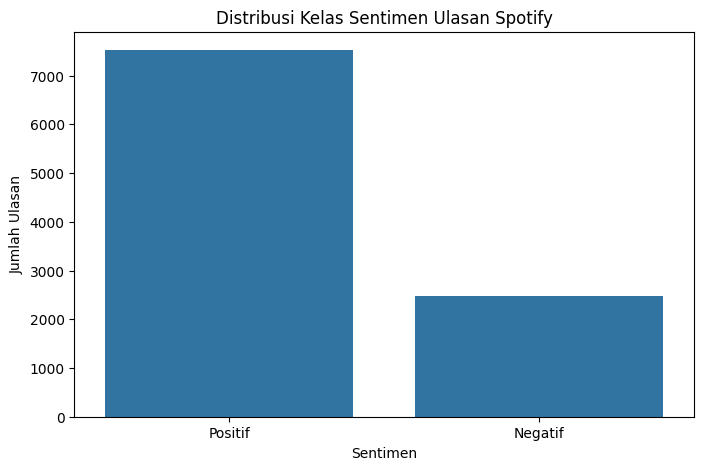

In [54]:
# Visualisasi distribusi kelas
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentimen', data=df, order=['Positif', 'Negatif'])
plt.title('Distribusi Kelas Sentimen Ulasan Spotify')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Sentimen')
plt.show()

In [55]:
# Cek data null
print("\nCek Data Null:")
print(df.isnull().sum())
df.dropna(subset=['Teks', 'Sentimen'], inplace=True)
print("Data null di 'Teks' atau 'Sentimen' telah dihapus.")


Cek Data Null:
Teks        0
Bintang     0
Tanggal     0
Sentimen    0
dtype: int64
Data null di 'Teks' atau 'Sentimen' telah dihapus.


In [56]:
# Membersihkan teks ulasan

# daftar stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    # Case folding (mengubah ke huruf kecil)
    text = text.lower()
    # Hapus angka
    text = re.sub(r"\d+", "", text)
    # Hapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)
    # Hapus spasi berlebih
    text = text.strip()
    # Tokenisasi
    tokens = word_tokenize(text)
    # Hapus stopwords
    cleaned_tokens = [word for word in tokens if word not in stop_words]

    return " ".join(cleaned_tokens)

In [57]:
# Terapkan fungsi preprocessing ke kolom 'Teks'
df['Teks_Bersih'] = df['Teks'].apply(preprocess_text)
print("Text preprocessing selesai.")

Text preprocessing selesai.


In [58]:
# Tampilkan perbandingan teks asli dan teks bersih
print("\nContoh Hasil Preprocessing:")
print("Teks Asli: ", df['Teks'].iloc[0])
print("Teks Bersih: ", df['Teks_Bersih'].iloc[0])


Contoh Hasil Preprocessing:
Teks Asli:  memberikan warna dalam setiap kesendirian
Teks Bersih:  warna kesendirian


In [60]:
# Tentukan X (fitur) dan y (target)
X = df['Teks_Bersih']
y_text = df['Sentimen']

# --- Encoding Label Target (y) ---
# Mengubah label teks (Positif, Negatif) menjadi angka
encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

# Simpan mapping label
# {0: 'Negatif', 1: 'Positif'} (atau sebaliknya)
label_mapping = {index: label for index, label in enumerate(encoder.classes_)}
print(f"\nMapping Label (Biner): {label_mapping}")

# --- Pembagian Data 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nJumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")


Mapping Label (Biner): {0: 'Negatif', 1: 'Positif'}

Jumlah data training: 8000
Jumlah data testing: 2000


Data Positif: 7525 | Data Negatif: 2475


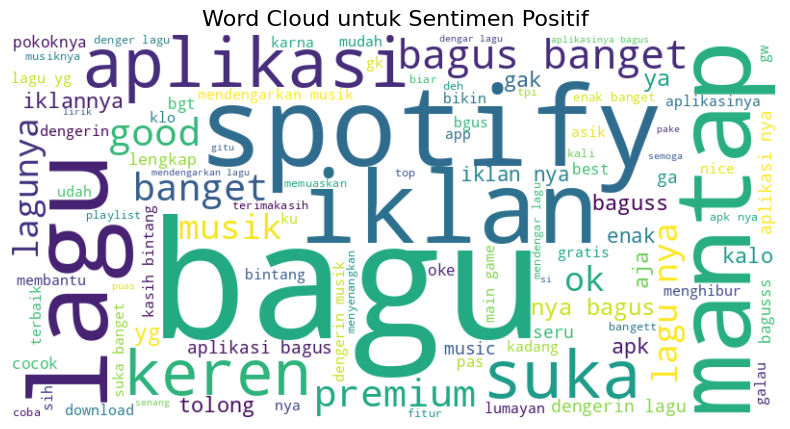

----------------------------------------------------------------------------------------------------


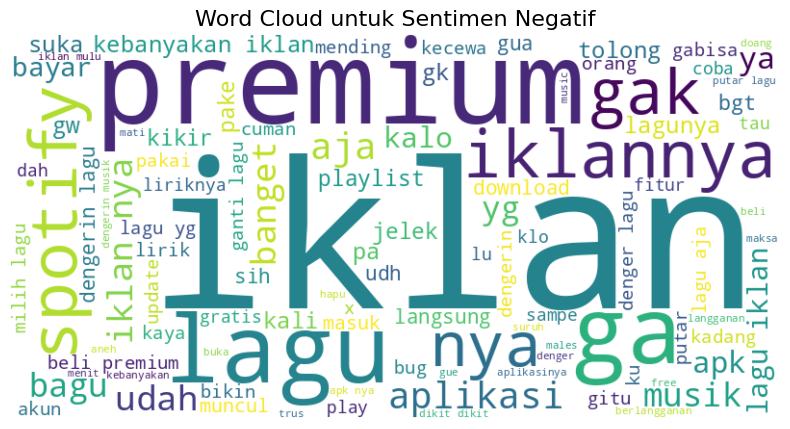

----------------------------------------------------------------------------------------------------


In [61]:
# ANALISIS FITUR & KEYWORD
# Kita akan cari tahu kata-kata apa yang paling dominan di setiap sentimen

# Pisahkan DataFrame berdasarkan sentimen
df_positif = df[df['Sentimen'] == 'Positif']
df_negatif = df[df['Sentimen'] == 'Negatif']

print(f"Data Positif: {len(df_positif)} | Data Negatif: {len(df_negatif)}")

def plot_top_keywords(df_sentiment, title):
    # Gabungkan semua teks bersih dari satu kategori sentimen
    # Pastikan tidak ada nilai NaN
    text = " ".join(review for review in df_sentiment['Teks_Bersih'].astype(str))

    if text.strip() == "":
        print(f"Tidak ada data untuk {title}. Dilewati.")
        return

    # Tampilkan Word Cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud untuk Sentimen {title}', fontsize=16)
    plt.show()

# 1. Analisis Sentimen POSITIF
plot_top_keywords(df_positif, "Positif")
print("-" * 100)

# 2. Analisis Sentimen NEGATIF
plot_top_keywords(df_negatif, "Negatif")
print("-" * 100)

# Kita akan melakukan 3 skema pelatihan:
# 1. SVM (Support Vector Machine) + TF-IDF
# 2. Multinomial Naive Bayes + TF-IDF
# 3. Deep Learning (LSTM) + Class Weight

In [62]:
# hasil akurasi akan disimpan di sebuah list untuk perbandingan
hasil_evaluasi = {}

In [63]:
# ------------------------------------------------
# SKEMA 1: SVM (Support Vector Machine) + TF-IDF
# ------------------------------------------------

# Ekstraksi Fitur dengan TF-IDF
# mempertimbangkan 5000 kata paling populer
vectorizer_tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

# Pelatihan Model SVM
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_tfidf, y_train)

# Evaluasi Model
y_pred_svm_train = model_svm.predict(X_train_tfidf)
y_pred_svm_test = model_svm.predict(X_test_tfidf)

acc_train_svm = accuracy_score(y_train, y_pred_svm_train)
acc_test_svm = accuracy_score(y_test, y_pred_svm_test)

print(f"\n--- Hasil SVM ---")
print(f"Akurasi Training: {acc_train_svm:.4f}")
print(f"Akurasi Testing: {acc_test_svm:.4f}")

# classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_svm_test, target_names=encoder.classes_))

# Simpan hasil
hasil_evaluasi['SVM + TF-IDF'] = {'Train Acc': acc_train_svm, 'Test Acc': acc_test_svm}


--- Hasil SVM ---
Akurasi Training: 0.9375
Akurasi Testing: 0.8725

Classification Report (Test Set):
              precision    recall  f1-score   support

     Negatif       0.79      0.66      0.72       495
     Positif       0.89      0.94      0.92      1505

    accuracy                           0.87      2000
   macro avg       0.84      0.80      0.82      2000
weighted avg       0.87      0.87      0.87      2000



In [64]:
# -------------------------------------------
# SKEMA 2: Multinomial Naive Bayes + TF-IDF
# -------------------------------------------

# Ekstraksi Fitur (Mengunakan TF-IDF yang sama dari Skema 1)
# X_train_tfidf dan X_test_tfidf yang sudah siap

# Pelatihan Model Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

# Evaluasi Model
y_pred_nb_train = model_nb.predict(X_train_tfidf)
y_pred_nb_test = model_nb.predict(X_test_tfidf)

acc_train_nb = accuracy_score(y_train, y_pred_nb_train)
acc_test_nb = accuracy_score(y_test, y_pred_nb_test)

print(f"\n--- Hasil Naive Bayes ---")
print(f"Akurasi Training: {acc_train_nb:.4f}")
print(f"Akurasi Testing: {acc_test_nb:.4f}")

# Tampilkan classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_nb_test, target_names=encoder.classes_))

# Simpan hasil
hasil_evaluasi['Naive Bayes + TF-IDF'] = {'Train Acc': acc_train_nb, 'Test Acc': acc_test_nb}


--- Hasil Naive Bayes ---
Akurasi Training: 0.9052
Akurasi Testing: 0.8540

Classification Report (Test Set):
              precision    recall  f1-score   support

     Negatif       0.86      0.49      0.63       495
     Positif       0.85      0.97      0.91      1505

    accuracy                           0.85      2000
   macro avg       0.85      0.73      0.77      2000
weighted avg       0.85      0.85      0.84      2000



In [65]:
# ----------------------------------------------------------
# SKEMA 3 : Deep Learning (LSTM) dengan Class Weight
# ----------------------------------------------------------

# Tentukan parameter tokenizer
vocab_size = 10000
max_length = 100
oov_tok = "<OOV>"

# Inisialisasi Tokenizer
tokenizer_dl = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer_dl.fit_on_texts(X_train)

# Ubah teks menjadi urutan angka (sequences)
X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

# Lakukan padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Ubah label y menjadi format One-Hot Encoding
num_classes = len(encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Bentuk X_train_pad: {X_train_pad.shape}")
print(f"Bentuk y_train_cat: {y_train_cat.shape}")

Bentuk X_train_pad: (8000, 100)
Bentuk y_train_cat: (8000, 2)


In [66]:
# Menghitung Class Weight
# Kita hitung bobotnya dari y_train (yang labelnya masih 0, 1, 2)
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Ubah ke format dictionary
class_weights_dict = {i : class_weights[i] for i in range(num_classes)}

print(f"\nClass Weighting yang akan dipakai (Kelas Minoritas punya bobot > 1):")
print(class_weights_dict)
print(f"(Mapping: {label_mapping})")


Class Weighting yang akan dipakai (Kelas Minoritas punya bobot > 1):
{0: np.float64(2.0202020202020203), 1: np.float64(0.6644518272425249)}
(Mapping: {0: 'Negatif', 1: 'Positif'})


In [67]:
embedding_dim = 128

model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size,
                         output_dim=embedding_dim,
                         input_length=max_length))
model_lstm.add(SpatialDropout1D(0.3))

# Gunakan Bidirectional LSTM agar model membaca dari 2 arah
model_lstm.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))

model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(num_classes, activation='softmax')) # Output layer

# Compile model
model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
# Pelatihan Model (Dengan Class Weight)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

num_epochs = 20
batch_size = 64

print("\nMemulai pelatihan model LSTM (Dengan Class Weight)...")
history = model_lstm.fit(
    X_train_pad, y_train_cat,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test_pad, y_test_cat),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=2
)


Memulai pelatihan model LSTM (Dengan Class Weight)...
Epoch 1/20
125/125 - 57s - 458ms/step - accuracy: 0.7656 - loss: 0.5028 - val_accuracy: 0.8545 - val_loss: 0.3648
Epoch 2/20
125/125 - 41s - 326ms/step - accuracy: 0.8826 - loss: 0.3371 - val_accuracy: 0.8865 - val_loss: 0.3276
Epoch 3/20
125/125 - 39s - 315ms/step - accuracy: 0.9135 - loss: 0.2633 - val_accuracy: 0.8750 - val_loss: 0.3428
Epoch 4/20
125/125 - 39s - 315ms/step - accuracy: 0.9334 - loss: 0.2238 - val_accuracy: 0.8480 - val_loss: 0.3808
Epoch 5/20
125/125 - 39s - 308ms/step - accuracy: 0.9408 - loss: 0.1979 - val_accuracy: 0.8635 - val_loss: 0.3638


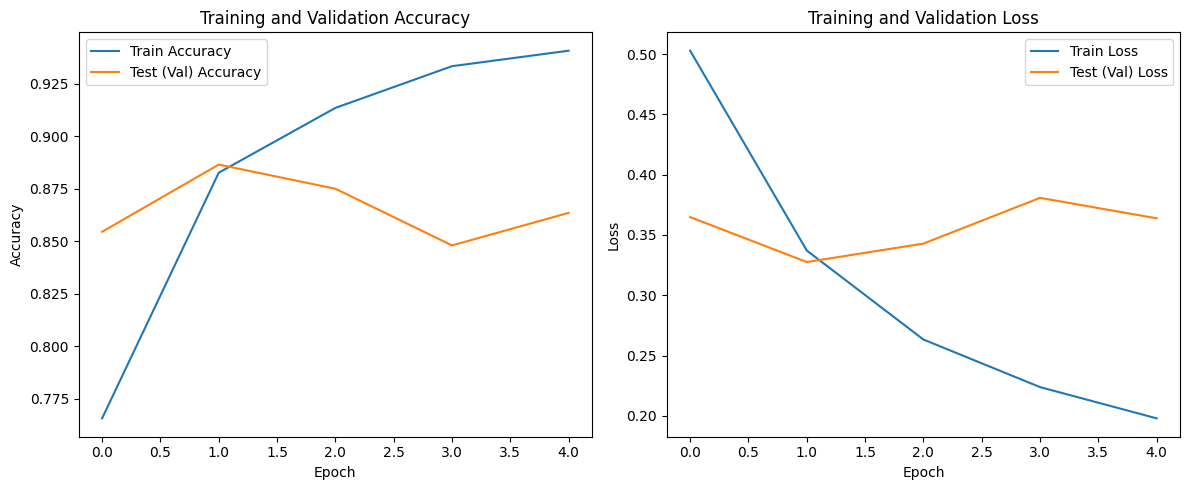

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8788 - loss: 0.3434

--- Hasil LSTM (Class Weight) ---
Akurasi Training: 0.8826
Akurasi Testing: 0.8865


In [69]:
# Evaluasi Model

plt.figure(figsize=(12, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test (Val) Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test (Val) Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluasi final pada test set
eval_result = model_lstm.evaluate(X_test_pad, y_test_cat)
acc_test_lstm = eval_result[1]

best_epoch_idx = np.argmax(history.history['val_accuracy'])
acc_train_lstm = history.history['accuracy'][best_epoch_idx]

print(f"\n--- Hasil LSTM (Class Weight) ---")
print(f"Akurasi Training: {acc_train_lstm:.4f}")
print(f"Akurasi Testing: {acc_test_lstm:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step

Classification Report (Test Set):
              precision    recall  f1-score   support

     Negatif       0.75      0.81      0.78       495
     Positif       0.93      0.91      0.92      1505

    accuracy                           0.89      2000
   macro avg       0.84      0.86      0.85      2000
weighted avg       0.89      0.89      0.89      2000



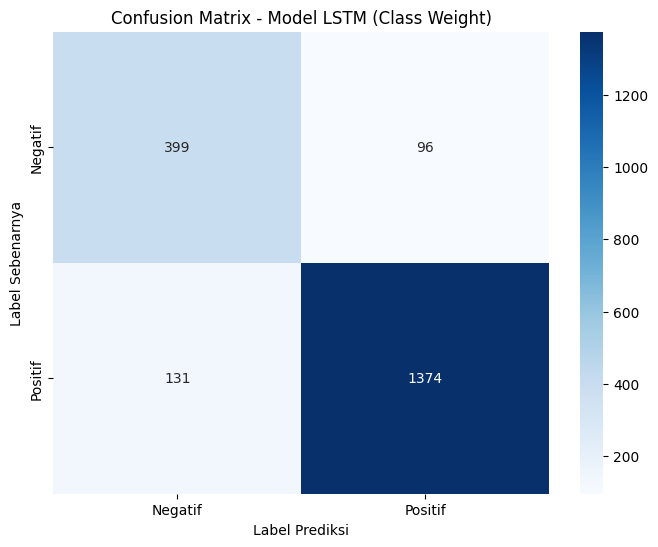

In [70]:
# Menampilkan classification report
y_pred_lstm_prob = model_lstm.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_lstm, target_names=encoder.classes_))

# Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Model LSTM (Class Weight)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

# Simpan hasil
hasil_evaluasi['LSTM (Class Weight)'] = {'Train Acc': acc_train_lstm, 'Test Acc': acc_test_lstm}

In [71]:
# | PERBANDINGAN HASIL 3 SKEMA |

print("--- Perbandingan 3 Skenario Pelatihan ---")

df_hasil = pd.DataFrame(hasil_evaluasi).T
df_hasil.sort_values(by='Test Acc', ascending=False, inplace=True)

print(df_hasil)

--- Perbandingan 3 Skenario Pelatihan ---
                      Train Acc  Test Acc
LSTM (Class Weight)    0.882625    0.8865
SVM + TF-IDF           0.937500    0.8725
Naive Bayes + TF-IDF   0.905250    0.8540


In [73]:
# | INFERENCE |

contoh_ulasan = [
    # Contoh POSITIF (Ekspektasi: Positif)
    "aplikasinya bagus banget, suka deh! lancar jaya",
    "Sudah cukup bagus, koleksi lagunya lengkap. Pertahankan!",

    # Contoh NEGATIF (Ekspektasi: Negatif)
    "kenapa sekarang jadi sering error? iklan mulu lagi, payah",
    "biasa aja sih, fiturnya standar. ga bagus ga jelek"
]

def prediksi_sentimen(list_teks):
    for teks_asli in list_teks:
        # Preprocessing teks baru
        teks_bersih = preprocess_text(teks_asli)

        # Ubah ke sequence (menggunakan 'tokenizer_dl' dari Skema 3)
        teks_seq = tokenizer_dl.texts_to_sequences([teks_bersih])

        # Padding (menggunakan 'max_length' dari Skema 3)
        teks_pad = pad_sequences(teks_seq, maxlen=max_length, padding='post', truncating='post')

        # Prediksi
        pred_prob = model_lstm.predict(teks_pad)

        # mencari kelas dengan probabilitas tertinggi
        pred_kelas_idx = np.argmax(pred_prob, axis=1)[0]

        # Ubah indeks kelas menjadi label teks
        pred_label = label_mapping[pred_kelas_idx]

        print(f"Ulasan: '{teks_asli}'")
        print(f"Prediksi Sentimen: -> {pred_label} (Prob: {np.max(pred_prob)*100:.2f}%)")
        print("-" * 30)

# Jalankan fungsi prediksi
prediksi_sentimen(contoh_ulasan)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Ulasan: 'aplikasinya bagus banget, suka deh! lancar jaya'
Prediksi Sentimen: -> Positif (Prob: 89.86%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Ulasan: 'Sudah cukup bagus, koleksi lagunya lengkap. Pertahankan!'
Prediksi Sentimen: -> Positif (Prob: 98.15%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Ulasan: 'kenapa sekarang jadi sering error? iklan mulu lagi, payah'
Prediksi Sentimen: -> Negatif (Prob: 99.09%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Ulasan: 'biasa aja sih, fiturnya standar. ga bagus ga jelek'
Prediksi Sentimen: -> Negatif (Prob: 96.62%)
------------------------------
